In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline



In [6]:
df = pd.read_excel("Copy of Cleaned_data.xlsx")

In [7]:
df.head()
df.tail()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NO Coupon,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08
1199,ORD201199,2023-06-11,C57502,Tablet,4,560.58,201 Main St,Gift Card,Returned,TRK51116746,6,SAVE10,Referral,2242.32


In [8]:
df.shape

(1200, 14)

In [9]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [11]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [12]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

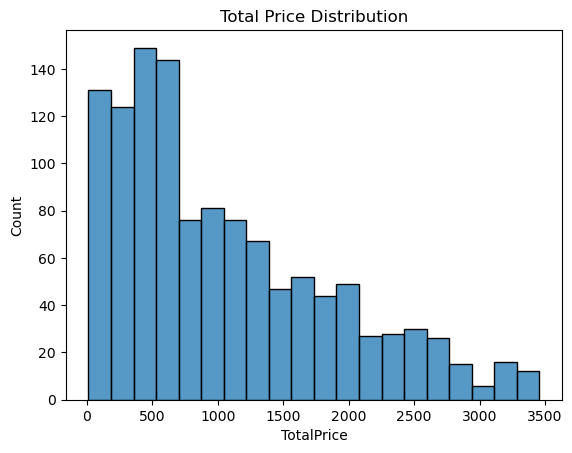

In [22]:
sns.histplot(df['TotalPrice'], bins=20)
plt.title('Total Price Distribution')
plt.show()

In [20]:
df['TotalPrice'].dtype

dtype('float64')

- Most orders have a Total Price below 1,000
- The data is right-skwewed(many small orders, few large ones.)

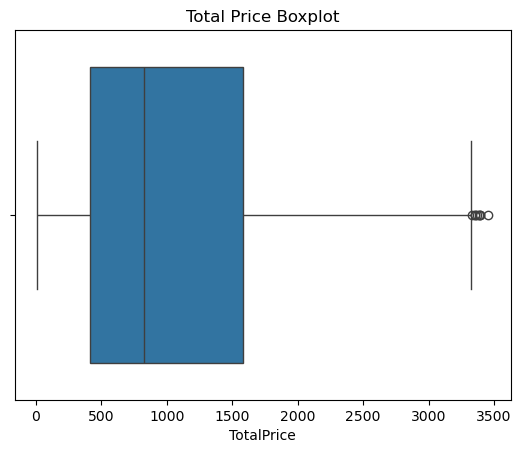

In [24]:
sns.boxplot (x=df['TotalPrice'])
plt.title("Total Price Boxplot")
plt.show()

The boxplot of Total Price shows that most orders fall within a typical price range. A few orders have much higher total price (around $3,300-$3,500), indicating the presence of outliers.

In [27]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

df[df['TotalPrice'] > upper_limit]

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,NO Coupon,Facebook,3384.90
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,NO Coupon,Facebook,3390.95


The total price column contains a few high value outliers. These orders have total prices around $3,300 - $3,450, which are significantly higher than the majority of orders. Since the totals are consistent with the quantity and unit price, these appear to be legitimate high value purchases rather than data entry errors.

In [28]:
outliers = df[df['TotalPrice'] > upper_limit]
print("Number of outliers:", len(outliers))

Number of outliers: 8


In [29]:
outliers[['CustomerID', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice']]

,CustomerID,Product,Quantity,UnitPrice,TotalPrice
107,C16775,Printer,5,670.75,3353.75
326,C65986,Laptop,5,670.48,3352.40
328,C18404,Tablet,5,674.04,3370.20
469,C13877,Chair,5,676.98,3384.90
632,C67260,Laptop,5,678.16,3390.80
789,C57276,Tablet,5,691.28,3456.40
1065,C47778,Printer,5,666.80,3334.00
1122,C38840,Monitor,5,678.19,3390.95


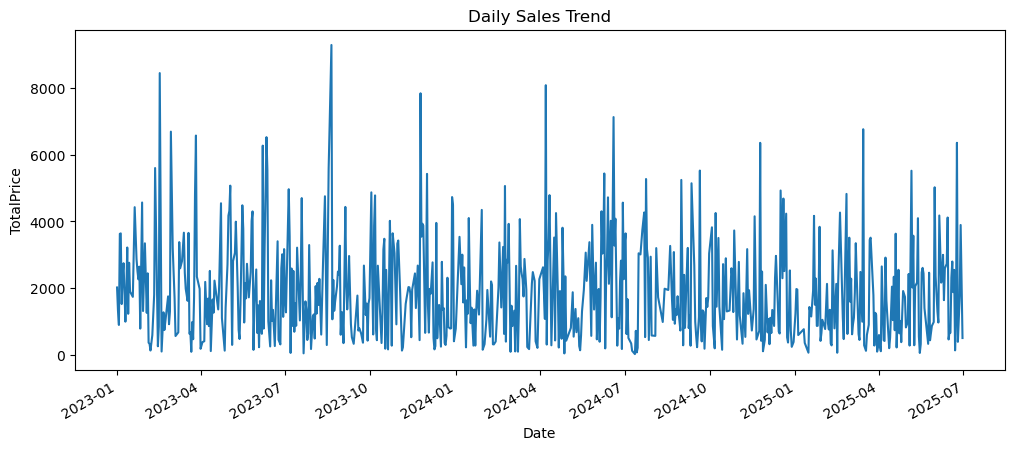

In [32]:
daily_sales = df.groupby('Date')['TotalPrice'].sum()

plt.figure(figsize=(12,5))
daily_sales.plot()
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("TotalPrice")
plt.show()

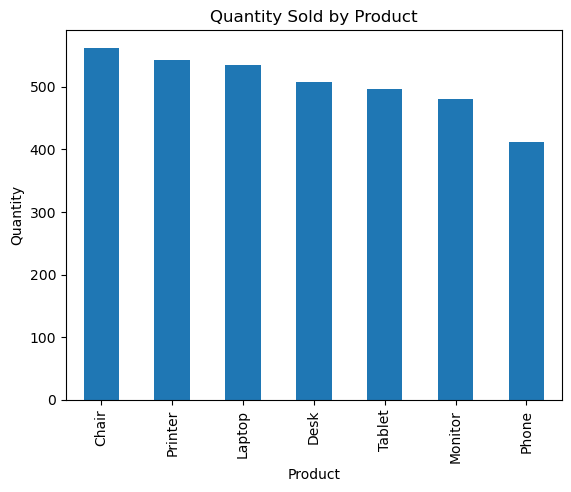

In [31]:
product_sales = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)

product_sales.plot(kind='bar')
plt.title("Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.show()

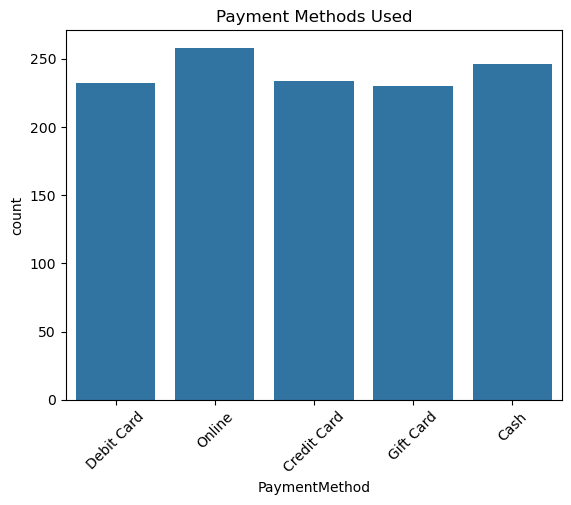

In [33]:
sns.countplot(data=df, x='PaymentMethod')
plt.title("Payment Methods Used")
plt.xticks(rotation=45)
plt.show()

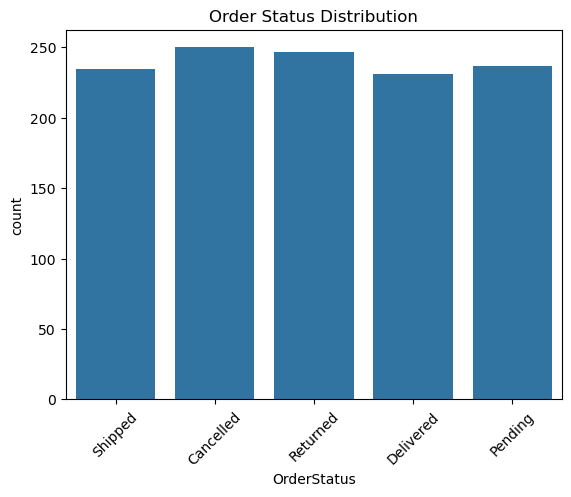

In [34]:
sns.countplot(data=df, x='OrderStatus')
plt.title("Order Status Distribution")
plt.xticks(rotation=45)
plt.show()